<a href="https://colab.research.google.com/github/mennamoha914-dotcom/SSIS/blob/master/Task_decodelabs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI Healthcare Analytics**
Heart Disease Prediction

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Load Dataset

df = pd.read_csv('/content/heart.csv')

In [ ]:
# Dataset Overview

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol  

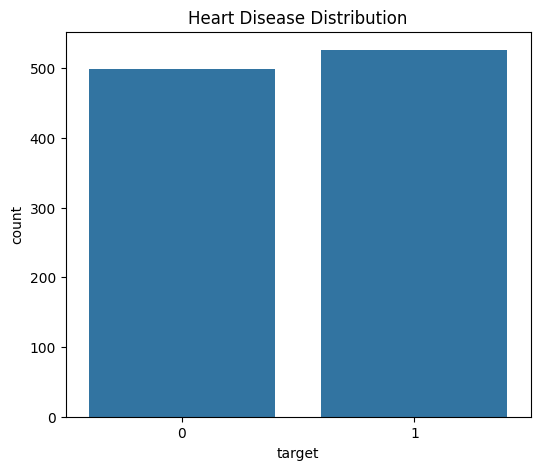

In [ ]:
# Data Visualization

# Target Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

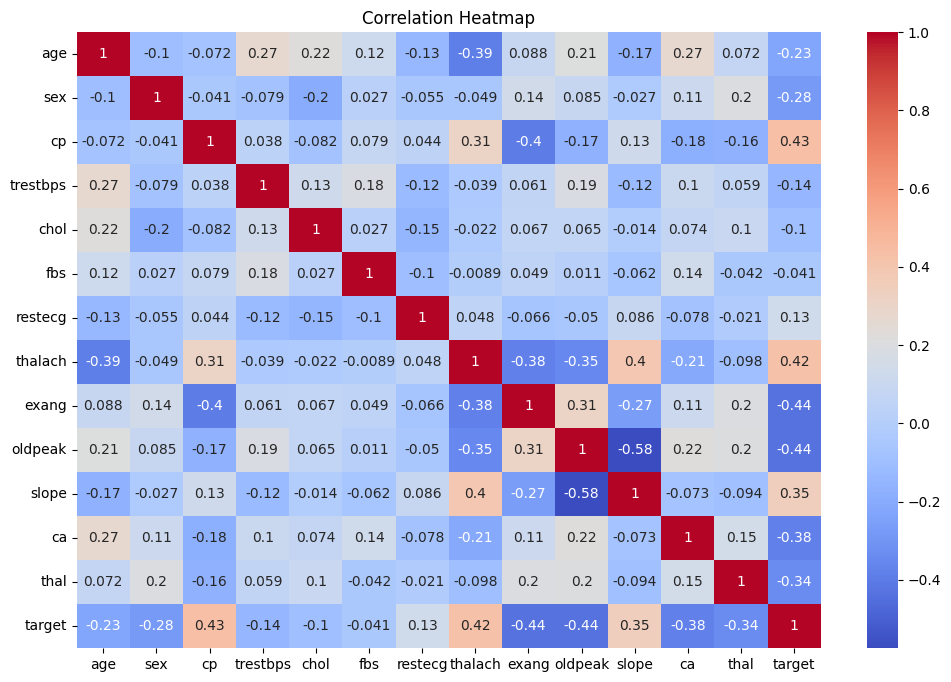

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

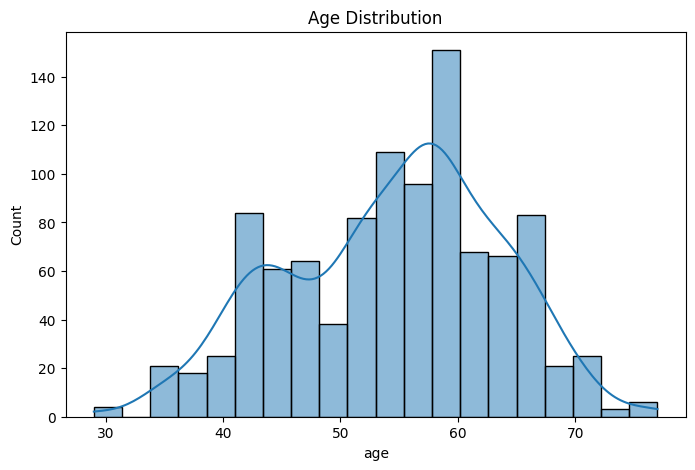

In [ ]:
# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

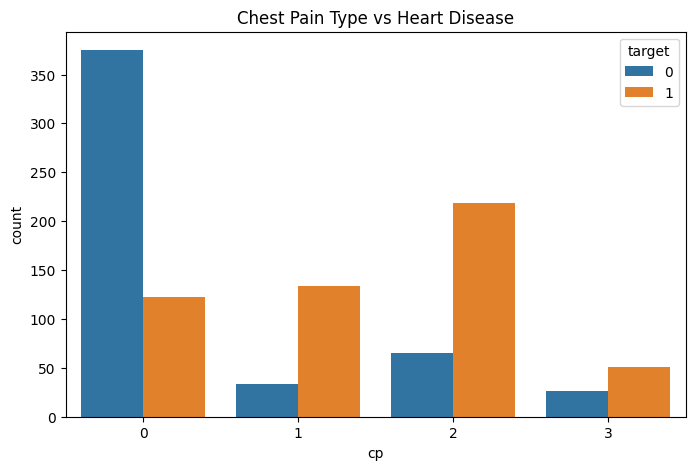

In [ ]:
# Chest Pain Type
plt.figure(figsize=(8,5))
sns.countplot(x='cp', hue='target', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

In [ ]:
# Data Preprocessing
X = df.drop('target', axis=1)
y = df['target']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [ ]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Logistic Regression
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("\n Logistic Regression ")
print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))


 Logistic Regression 
Accuracy: 0.7951219512195122

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



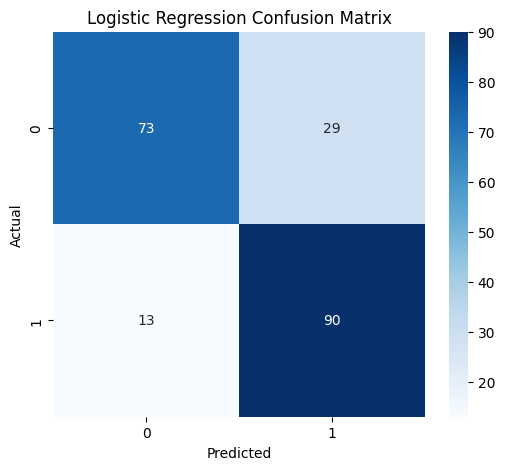

In [ ]:
#confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("\nRandom Forest ")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


Random Forest 
Accuracy: 0.9853658536585366

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



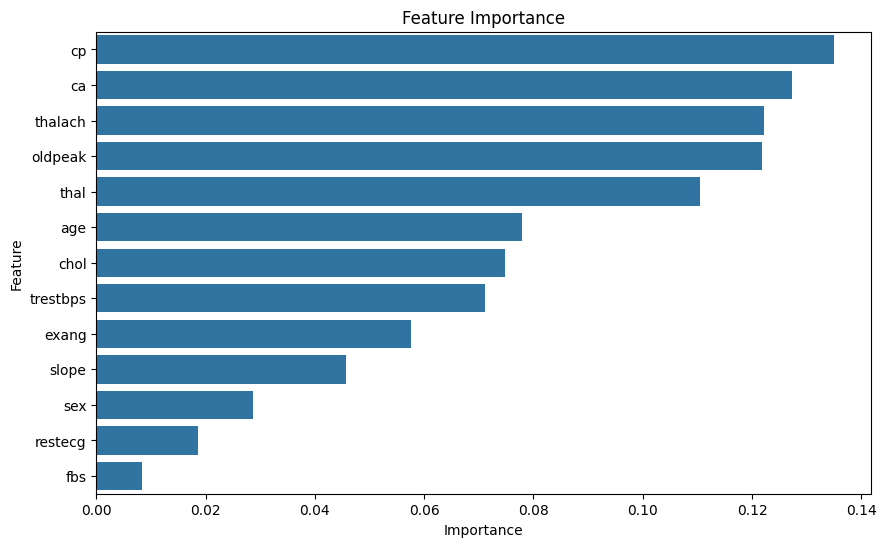

In [ ]:
#Feature Importance
importance = rf_model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance")
plt.show()


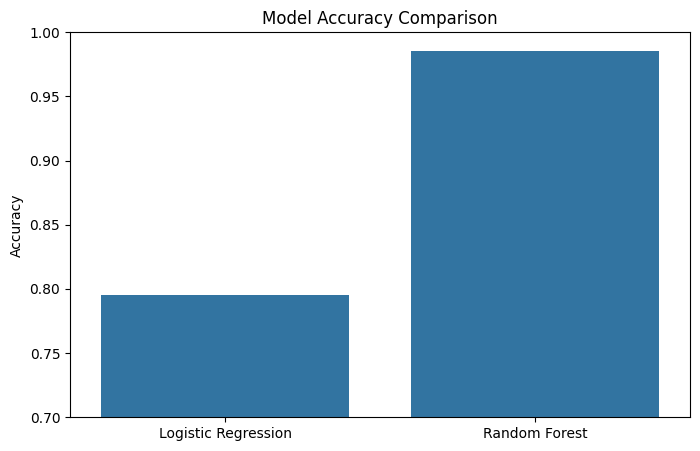

In [ ]:
#Final Comparison
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)

models = ['Logistic Regression', 'Random Forest']
accuracies = [lr_acc, rf_acc]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies)

plt.ylim(0.7, 1.0)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
!pip install xgboost

In [ ]:
# Model Comparison Table

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Create Models

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}


results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store Results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

# Create DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

# Sort Results

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

# Display Results

print(results_df)

print("\nInsight:")
print("Comparing multiple models helps identify the most effective algorithm for heart disease prediction.")

                 Model  Accuracy  Precision    Recall  F1 Score
1        Decision Tree  0.985366   1.000000  0.970874  0.985222
2        Random Forest  0.985366   1.000000  0.970874  0.985222
3              XGBoost  0.985366   1.000000  0.970874  0.985222
0  Logistic Regression  0.795122   0.756303  0.873786  0.810811

Insight:
Comparing multiple models helps identify the most effective algorithm for heart disease prediction.


In [ ]:
#Final Insights
print("\n Final Insights ")
print("1. Random Forest usually performs better.")
print("2. Chest pain and max heart rate are important features.")
print("3. Dataset analysis helps predict heart disease early.")


 Final Insights 
1. Random Forest usually performs better.
2. Chest pain and max heart rate are important features.
3. Dataset analysis helps predict heart disease early.
